## 1. 데이터 생성

In [1]:
import pandas as pd

athletes = pd.DataFrame({
    "athlete": [
        "서윤", "도현", "하린", "민재",
        "유나", "태민", "시우", "다은",
        "건우", "예린", "준호", "소민"
    ],
    "team": [
        "A", "A", "A", "A", "A", "A",
        "B", "B", "B", "B", "B", "B"
    ],
    "sport": [
        "육상", "육상",
        "수영", "수영",
        "사이클", "사이클",
        "육상", "육상",
        "수영", "수영",
        "사이클", "사이클"
    ],
    "performance_score": [
        88, 92,
        84, 86,
        90, 94,
        82, 85,
        80, 83,
        87, 89
    ]
})

athletes

,athlete,team,sport,performance_score
0,서윤,A,육상,88
1,도현,A,육상,92
2,하린,A,수영,84
3,민재,A,수영,86
4,유나,A,사이클,90
5,태민,A,사이클,94
6,시우,B,육상,82
7,다은,B,육상,85
8,건우,B,수영,80
9,예린,B,수영,83


## 2. 막대그래프(Bar Plot)

> ### 2-1 ) 종목별 평균 경기력 계산

In [2]:
sport_score = (
    athletes
    .groupby("sport")[
        "performance_score"
    ]
    .mean()
)

print(sport_score)

sport
사이클    90.00
수영     83.25
육상     86.75
Name: performance_score, dtype: float64


> ### 2-2 ) plt.bar()로 종목 비교

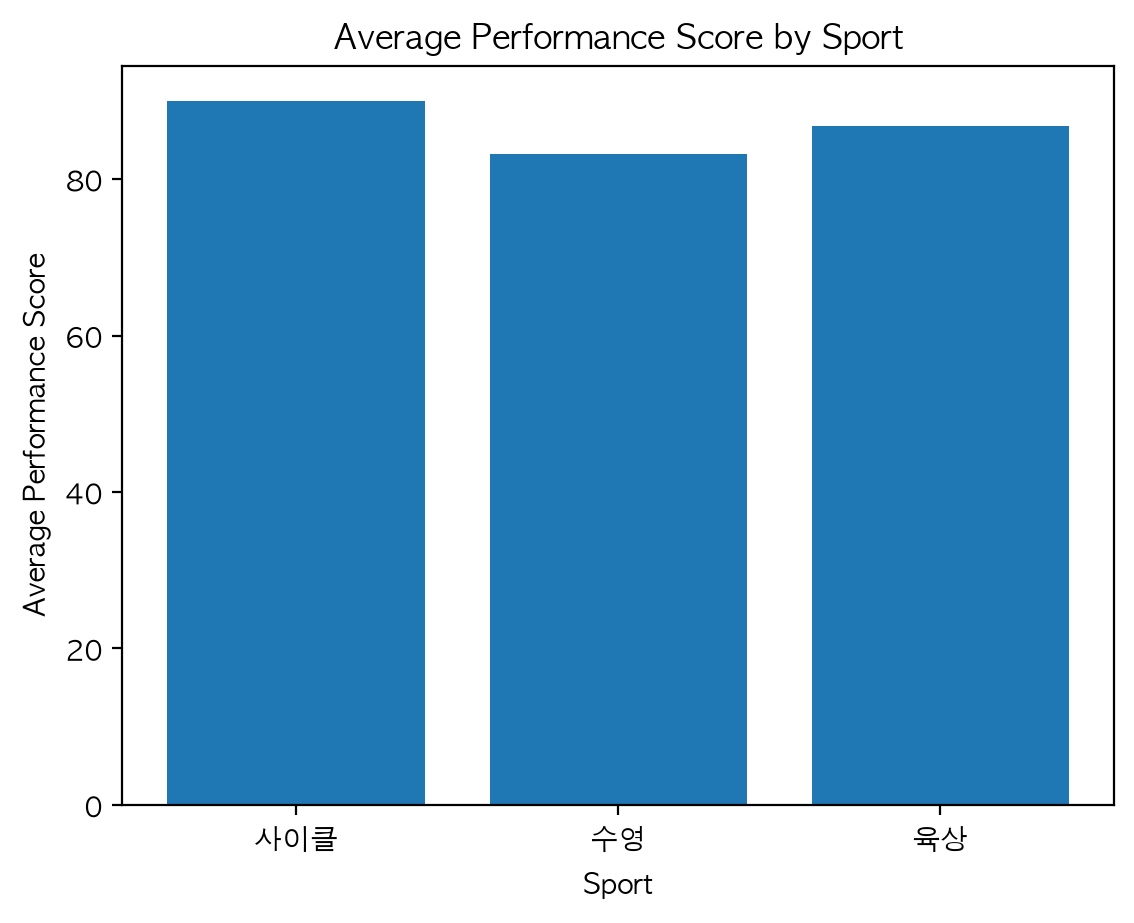

In [ ]:
import matplotlib.pyplot as plt
import platform
%config InlineBackend.figure_format = 'retina'

# 한글폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"

elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# Visualization
plt.bar(
    sport_score.index,
    sport_score.values
)

plt.xlabel("Sport")
plt.ylabel("Average Performance Score")
plt.title("Average Performance Score by Sport")

plt.show()

## 3. 수직·수평 막대와 정렬


> ### 3-1 ) 값이 높은 순서대로 정렬

In [4]:
sport_score_desc = (
    sport_score
    .sort_values(
        ascending=False
    )
)

print(sport_score_desc)

sport
사이클    90.00
육상     86.75
수영     83.25
Name: performance_score, dtype: float64


> ### 3-2 ) 정렬된 수직 막대그래프

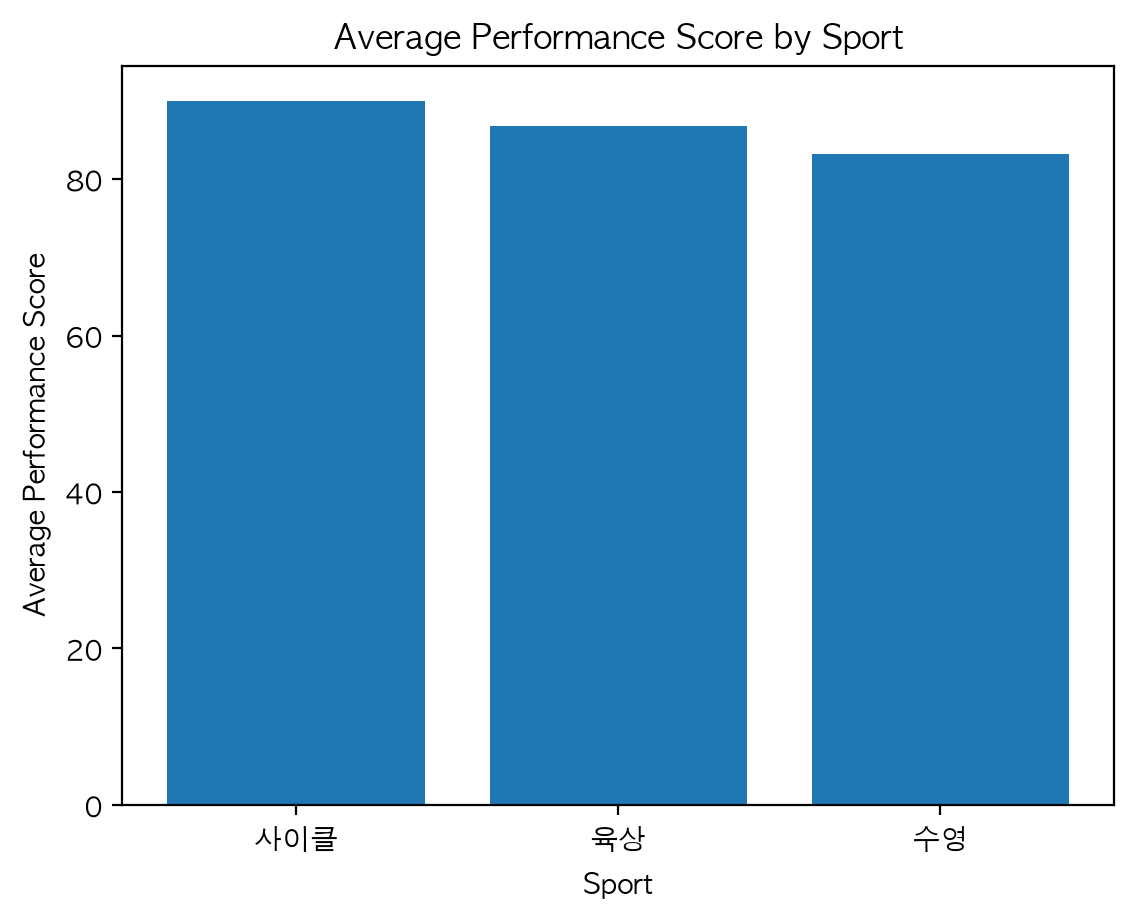

In [5]:
plt.bar(
    sport_score_desc.index,
    sport_score_desc.values
)

plt.xlabel("Sport")
plt.ylabel("Average Performance Score")
plt.title("Average Performance Score by Sport")

plt.show()

> ### **3-4 ) 수평 막대그래프**



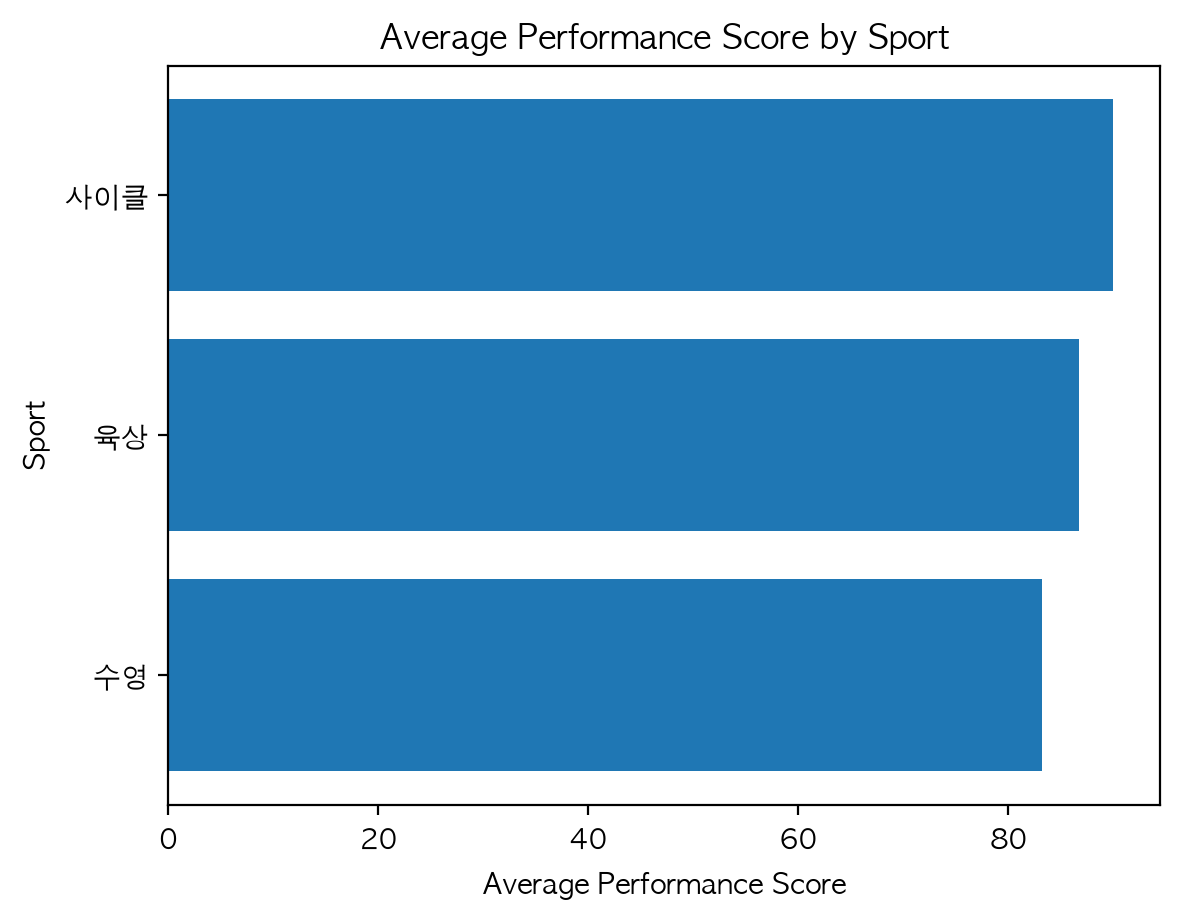

In [6]:
sport_score_asc = (
    sport_score
    .sort_values(
        ascending=True
    )
)

plt.barh(
    sport_score_asc.index,
    sport_score_asc.values
)

plt.xlabel("Average Performance Score")
plt.ylabel("Sport")
plt.title("Average Performance Score by Sport")

plt.show()

## **4. 그룹 막대그래프(Grouped Bar Plot)**



> ### **4-1 ) 종목별 A팀·B팀 평균 경기력**



In [7]:
team_sport_score = athletes.groupby(["sport", "team"])["performance_score"].mean()


print(team_sport_score)

sport  team
사이클    A       92.0
       B       88.0
수영     A       85.0
       B       81.5
육상     A       90.0
       B       83.5
Name: performance_score, dtype: float64


> ### **4-2 ) sns.barplot()과 hue**



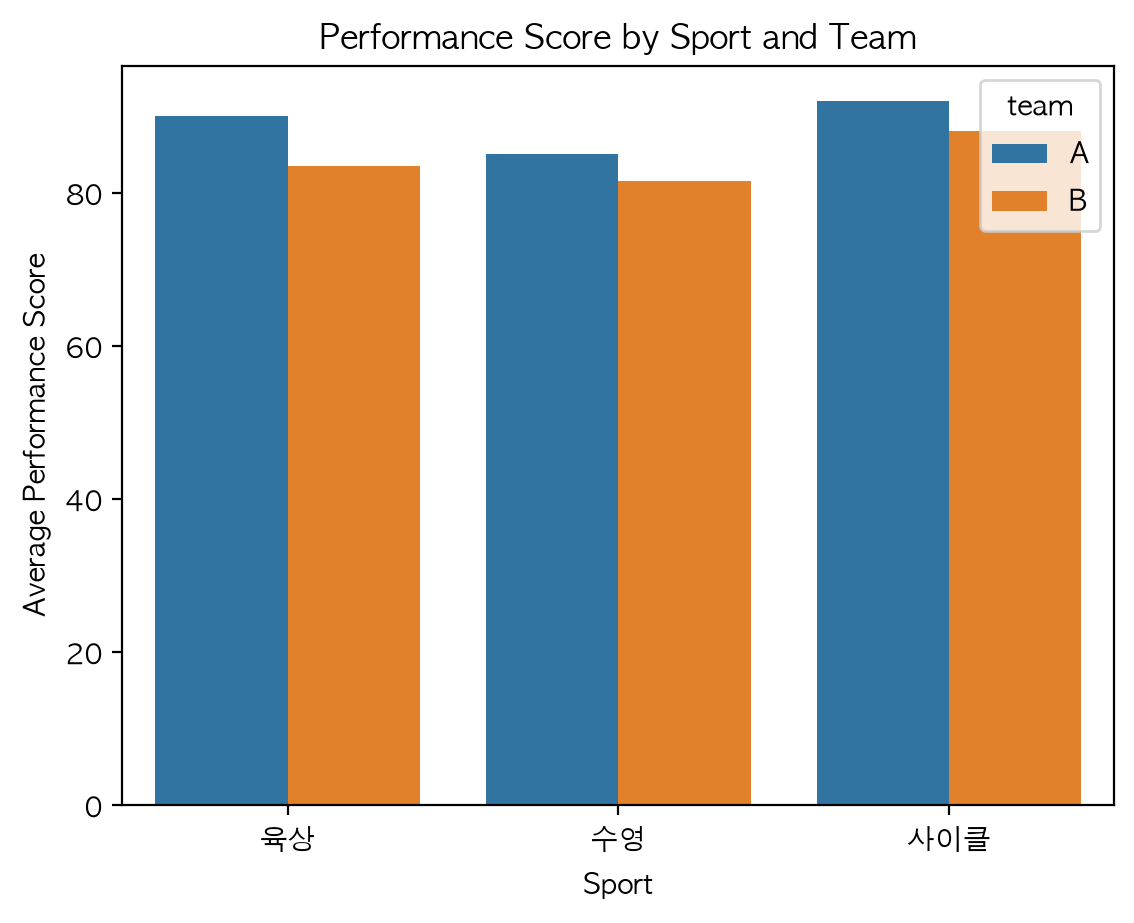

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=athletes,
    x="sport",
    y="performance_score",
    hue="team",
    errorbar=None
)

plt.xlabel("Sport")
plt.ylabel("Average Performance Score")
plt.title("Performance Score by Sport and Team")

plt.show()

## **5. sns.barplot()의 에러바**



> ### **5-1 ) 에러바의 의미**



<Axes: xlabel='sport', ylabel='performance_score'>

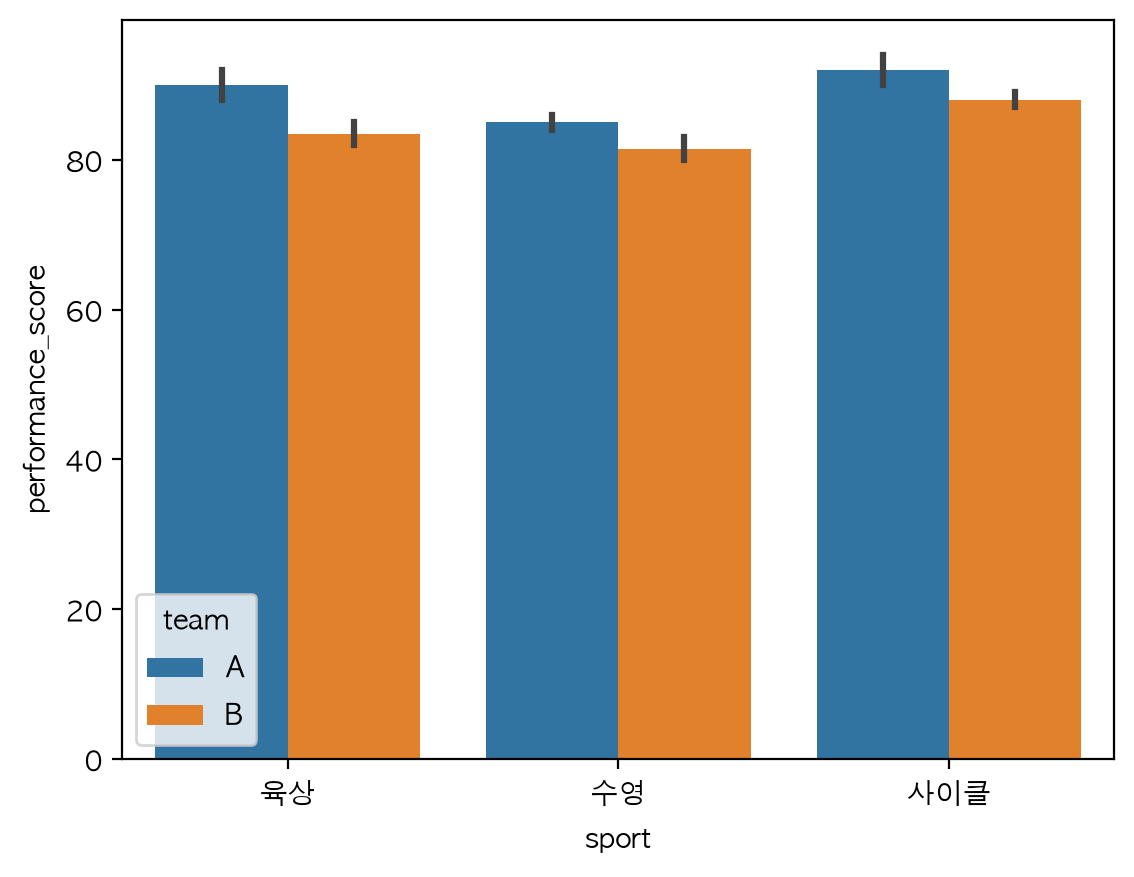

In [9]:
sns.barplot(
    data=athletes,
    x="sport",
    y="performance_score",
    hue="team",
    errorbar=("ci", 95)
)


> ### **5-2 ) 평균 막대만 비교**



<Axes: xlabel='sport', ylabel='performance_score'>

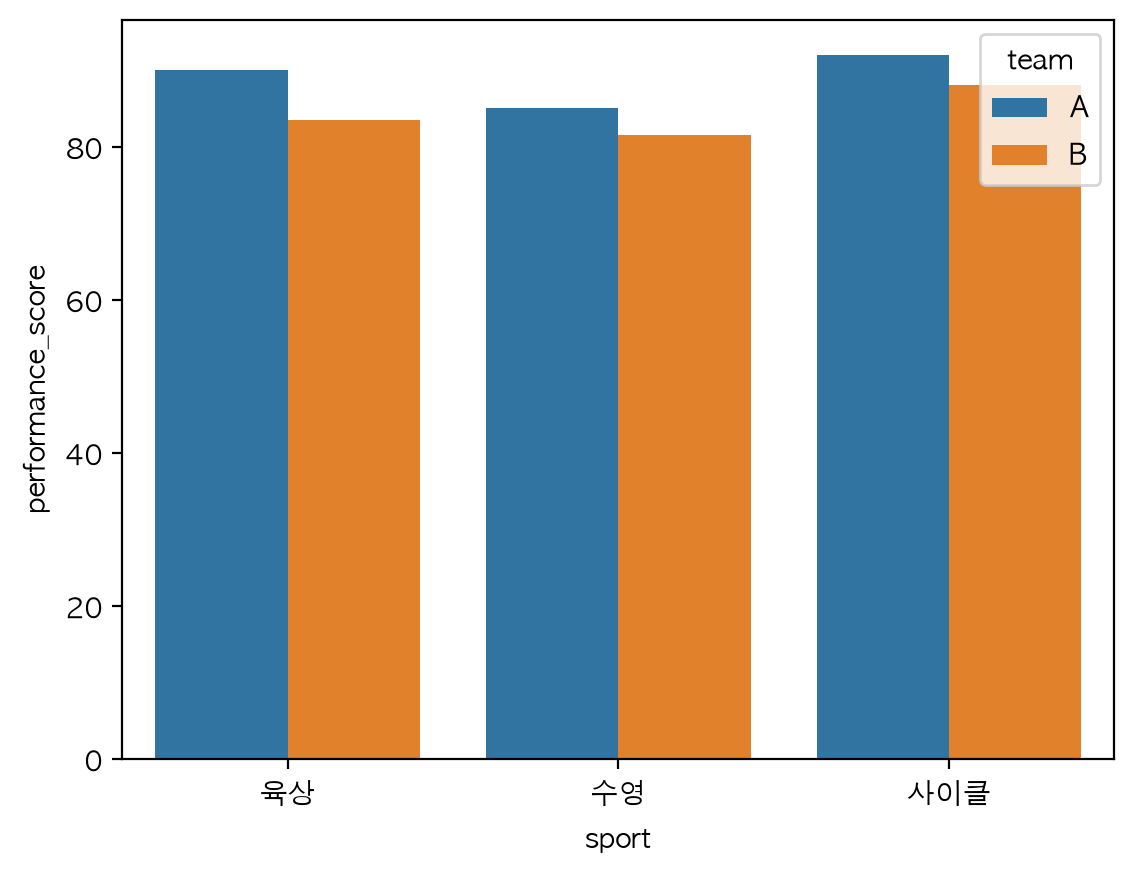

In [10]:
sns.barplot(
    data=athletes,
    x="sport",
    y="performance_score",
    hue="team",
    errorbar=None
)